In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import BaseEstimatorV2
from qiskit.circuit.library import XGate
from qiskit.circuit.library import efficient_su2
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis,
    PadDynamicalDecoupling,
)

import hamiltonian_generator

from qiskit.primitives import StatevectorEstimator
from qiskit_ibm_runtime import QiskitRuntimeService, Session, EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2

from itertools import product

import warnings
warnings.filterwarnings("ignore")

In [2]:
def spsa(
    fun, x0, args=(), A=30, alpha=0.9, a=0.3, c=0.1, gamma=0.4, maxiter=100
):
    nparams = len(x0)
    x = np.copy(x0)

    for i in range(maxiter):
        a_i = a / (A + i + 1) ** alpha
        c_i = c / (i + 1) ** gamma
        delta_i = np.random.choice([-1, 1], nparams)

        # two hardware calls
        eval_1 = fun(x + c_i * delta_i, *args)
        eval_2 = fun(x - c_i * delta_i, *args)

        # compute the gradient and update the parameters
        grad = (eval_1 - eval_2) / (2 * c_i) * np.reciprocal(delta_i)
        x = x - a_i * grad

    return x

In [3]:
def cost_func(
    params: Sequence,
    ansatz: QuantumCircuit,
    hamiltonian: SparsePauliOp,
    estimator: BaseEstimatorV2,
    cost_history_dict: dict,
) -> float:
    
    """Ground state energy evaluation."""
    energy = (
        estimator.run([(ansatz, hamiltonian, [params])]).result()[0].data.evs
    )

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = list(params)
    cost_history_dict["cost_history"].append(float(energy[0]))

    print(
        f"Fx Iters. done: {cost_history_dict['iters']} [Current cost: {round(energy[0], 5)}]",
        end="\r",
    )

    return energy


def solve(x0, isa_ansatz, isa_observable, maxiter=150):
    cost_history_dict = {
        "prev_vector": None,
        "iters": 0,
        "cost_history": [],
        "y_min": None,
    }

    # Evaluate the problem using a QPU via Qiskit IBM Runtime
    estimator = StatevectorEstimator()
    estimator.skip_transpilation = True
    x_opt = spsa(
        cost_func,
        x0=x0,
        args=(isa_ansatz, isa_observable, estimator, cost_history_dict),
        maxiter=maxiter,
    )

    y_min = cost_func(
        x_opt, isa_ansatz, isa_observable, estimator, cost_history_dict
    )

    return y_min, cost_history_dict

In [4]:
def visualize_results(results, gse):
    plt.plot(results["cost_history"], lw=2)
    plt.axhline(y=gse, color='black', linestyle='--', linewidth=2)
    plt.xlabel("Number of function evaluations")
    plt.ylabel("Energy")
    plt.show()

In [5]:
def train(n, h) :
    ansatz = efficient_su2(num_qubits=n, reps=2)
    backend = FakeGuadalupeV2()
    ansatz.draw("mpl", style="iqp")
    
    target = backend.target
    pm = generate_preset_pass_manager(optimization_level=3, target=target)
    isa_ansatz = pm.run(ansatz)

    hamiltonian = hamiltonian_generator.get_heisenberg_hamiltonian(n, h)

    eigenvalues = np.linalg.eigvalsh(hamiltonian.to_matrix())
    gse = np.min(eigenvalues)

    print(f"True ground state energy for n={n}, h={h}: {gse}")

    isa_observable = hamiltonian.apply_layout(isa_ansatz.layout)
    isa_ansatz.draw("mpl", scale=0.6, style="iqp", fold=-1, idle_wires=False)

    np.random.seed(42)
    num_params = ansatz.num_parameters
    params = 2 * np.pi * np.random.random(num_params)

    maxiter = 5000
    spsa_min, spsa_history = solve(
        params, isa_ansatz, isa_observable, maxiter=maxiter
    )
    print(f"Estimated ground state energy for n={n}, h={h}: {spsa_min}")

    visualize_results(spsa_history, gse)

    opt_params = spsa_history['prev_vector']
    np.save(f'params/params_{n}_{h}', opt_params)

True ground state energy for n=12, h=0: -20.568362531362194
Estimated ground state energy for n=12, h=0: [-17.23164431]


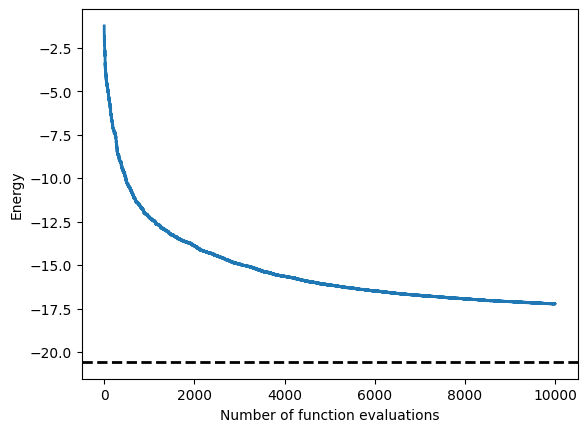

True ground state energy for n=12, h=0.5: -20.56836253136204
Estimated ground state energy for n=12, h=0.5: [-16.24323482]


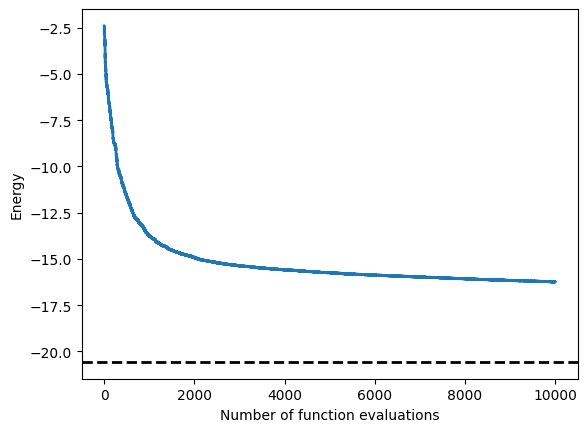

True ground state energy for n=12, h=2: -24.03965118258929
Estimated ground state energy for n=12, h=2: [-20.07379294]


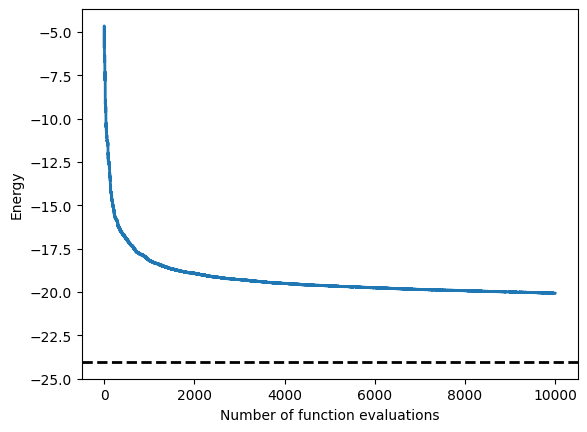

True ground state energy for n=12, h=5: -49.0
Estimated ground state energy for n=12, h=5: [-48.92667173]


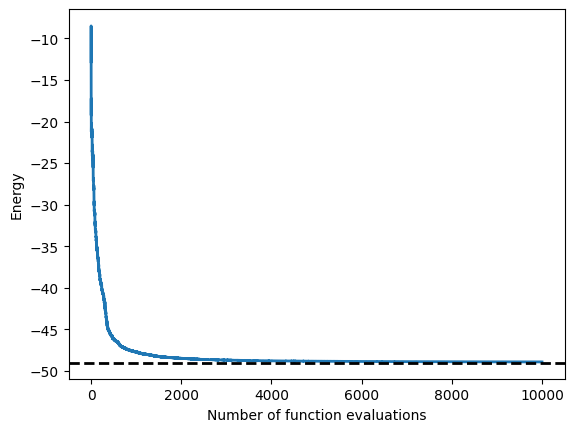

True ground state energy for n=8, h=0: -13.49973039475159
Estimated ground state energy for n=8, h=0: [-10.63638629]


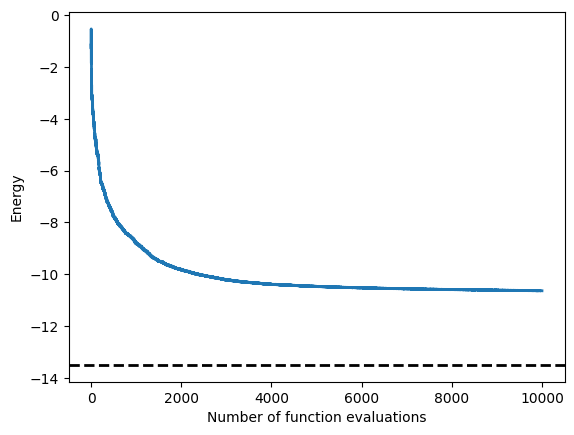

True ground state energy for n=8, h=0.5: -13.499730394751541
Estimated ground state energy for n=8, h=0.5: [-11.27621691]


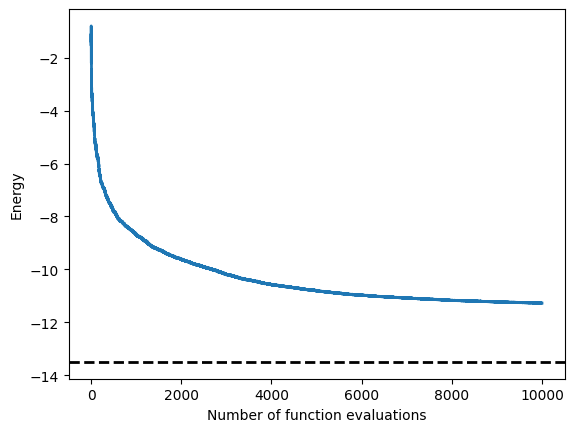

True ground state energy for n=8, h=2: -15.928961951051562
Estimated ground state energy for n=8, h=2: [-13.1308717]


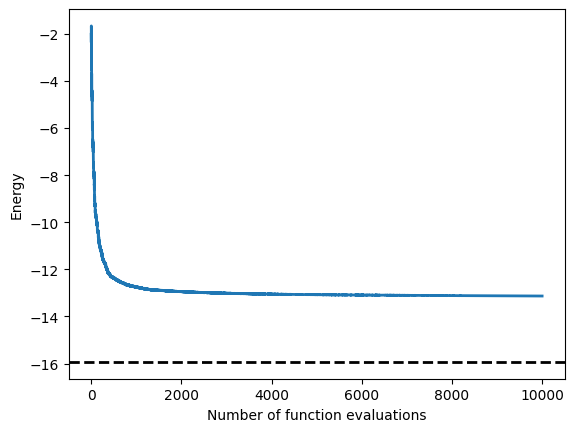

True ground state energy for n=8, h=5: -33.0
Estimated ground state energy for n=8, h=5: [-32.97485968]


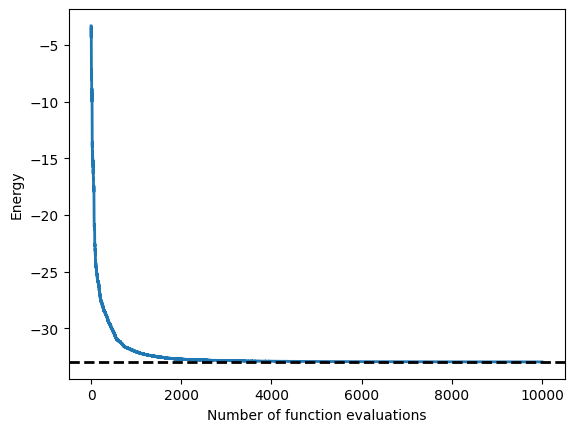

True ground state energy for n=5, h=0: -7.711545013271975
Estimated ground state energy for n=5, h=0: [-6.39785998]


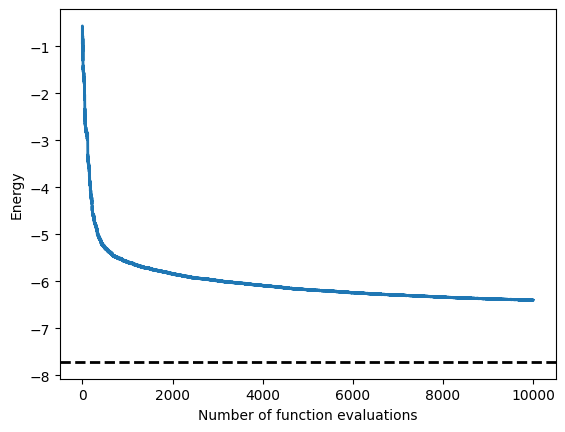

True ground state energy for n=5, h=0.5: -8.211545013271982
Estimated ground state energy for n=5, h=0.5: [-6.6102764]


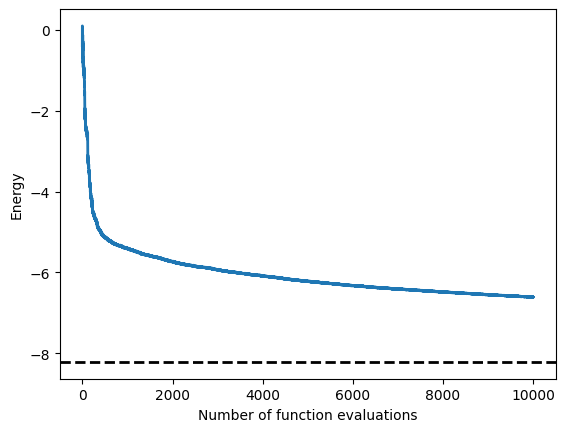

True ground state energy for n=5, h=2: -9.711545013271973
Estimated ground state energy for n=5, h=2: [-8.47608351]


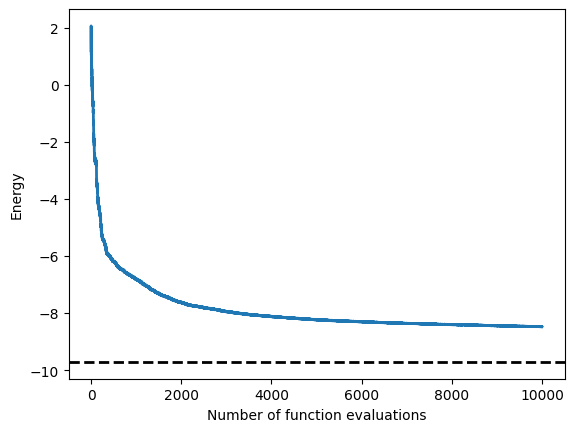

True ground state energy for n=5, h=5: -21.0
Estimated ground state energy for n=5, h=5: [-20.99943055]


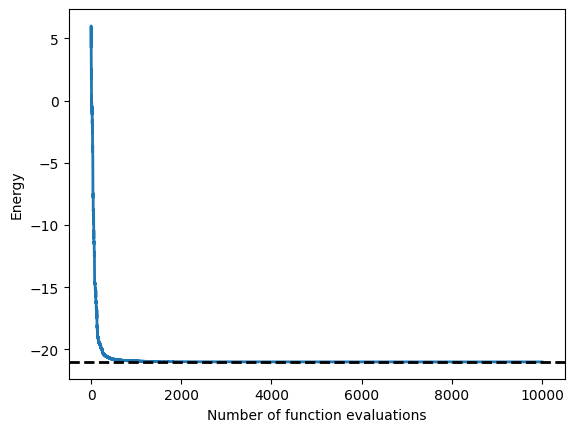

True ground state energy for n=3, h=0: -4.0
Estimated ground state energy for n=3, h=0: [-3.40798777]


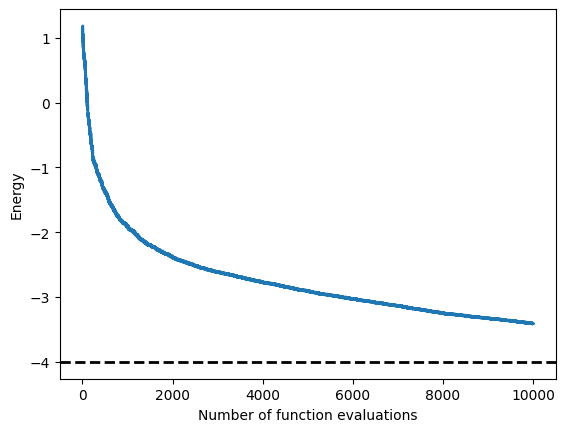

True ground state energy for n=3, h=0.5: -4.5
Estimated ground state energy for n=3, h=0.5: [-4.38379996]


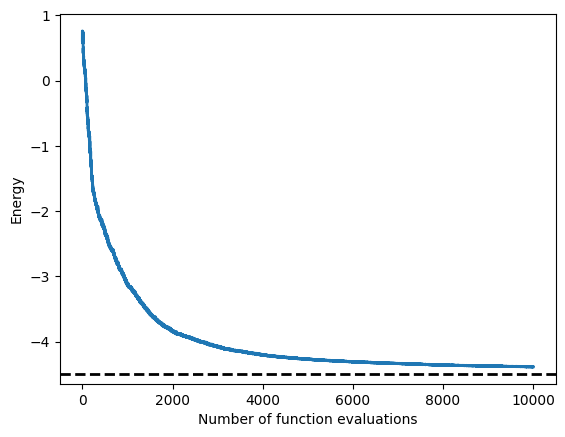

True ground state energy for n=3, h=2: -6.0
Estimated ground state energy for n=3, h=2: [-5.04254922]


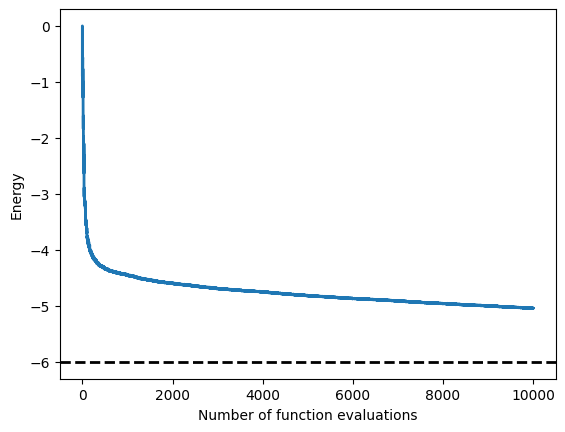

True ground state energy for n=3, h=5: -13.0
Estimated ground state energy for n=3, h=5: [-12.96603707]


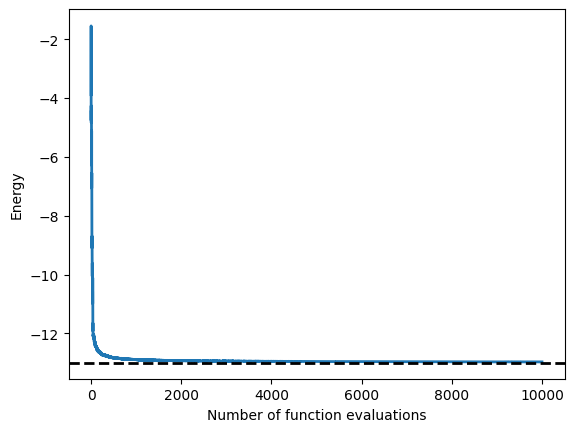

In [6]:
num_sites = [12, 8, 5, 3]
couplings = [0, 0.5, 2, 5]

for n, h in product(num_sites, couplings) :
    train(n, h)